In [1]:

import os
import math
import gc
import random
import json
import zipfile

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import FileLink

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

TARGET_ROWS = 1_500_000
NUM_NEGATIVES = 4
BATCH_SIZE = 2048
EMBEDDING_DIM = 384
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-3
EVAL_NEGATIVES = 99
EVAL_USERS = 5_000

print(f"Random seed: {SEED}")

In [ ]:

reviews_iter = pd.read_json(
    '/kaggle/input/datasets/pypiahmad/goodreads-book-reviews1/goodreads_reviews_dedup.json',
    lines=True,
    chunksize=100_000
)

_chunks, _rows_so_far = [], 0
for _chunk in reviews_iter:
    _chunks.append(_chunk)
    _rows_so_far += len(_chunk)
    if _rows_so_far >= TARGET_ROWS:
        break

interactions_df = pd.concat(_chunks, ignore_index=True).head(TARGET_ROWS)
del _chunks

interactions_df['rating'] = 1
interactions_df = interactions_df[['user_id', 'book_id', 'rating']]

interactions_df['user_id'] = interactions_df['user_id'].astype('category').cat.codes

interactions_df['book_id'] = interactions_df['book_id'].astype(str)
book_id_cat = interactions_df['book_id'].astype('category')

book_code_to_raw_id = dict(enumerate(book_id_cat.cat.categories))
book_raw_id_to_code = {
    raw: code for code, raw in book_code_to_raw_id.items()
}

interactions_df['book_id'] = book_id_cat.cat.codes

num_users = interactions_df['user_id'].nunique()
num_items = interactions_df['book_id'].nunique()

print(f"Users: {num_users} | Books: {num_items}")

Users: 29860 | Books: 519608


In [ ]:

test_df = interactions_df.groupby('user_id').sample(n=1, random_state=42)
train_df = interactions_df.drop(test_df.index).reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train: {len(train_df):,} | Test: {len(test_df):,}")

Train: 1,470,140 | Test: 29,860


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [ ]:

transformer_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)

full_content_embeddings = torch.zeros(
    (num_items, EMBEDDING_DIM),
    dtype=torch.float32,
    device=device
)

needed_ids = set(book_raw_id_to_code.keys())
matched_book_ids = set()
book_title_lookup = {}

books_raw = pd.read_json(
    '/kaggle/input/datasets/pypiahmad/goodreads-book-reviews1/goodreads_books.json',
    lines=True,
    chunksize=10_000
)

for chunk in books_raw:
    if len(matched_book_ids) >= len(needed_ids):
        break

    chunk = chunk.fillna('')
    chunk['book_id'] = chunk['book_id'].astype(str)

    chunk = chunk[
        chunk['book_id'].isin(needed_ids)
        & ~chunk['book_id'].isin(matched_book_ids)
    ]

    if chunk.empty:
        continue

    chunk['combined_text'] = (
        "Title: " + chunk['title'] + " | " +
        "Author: " + chunk['authors'].astype(str) + " | " +
        "Description: " + chunk['description']
    )

    batch_embeddings = transformer_model.encode(
        chunk['combined_text'].tolist(),
        batch_size=256,
        show_progress_bar=False,
        convert_to_numpy=True
    )

    for raw_id, title, vec in zip(
        chunk['book_id'],
        chunk['title'],
        batch_embeddings
    ):
        code_idx = book_raw_id_to_code[raw_id]
        full_content_embeddings[code_idx] = torch.as_tensor(
            vec, dtype=torch.float32, device=device
        )
        matched_book_ids.add(raw_id)
        book_title_lookup[raw_id] = title

coverage = len(matched_book_ids) / max(len(needed_ids), 1) * 100
print(f"Metadata coverage: {coverage:.2f}%")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Matched content embeddings for 519,608 / 519,608 books (100.0% coverage). Unmatched books keep a zero vector.
Content embedding matrix shape: torch.Size([519608, 384])


# **Embedding sanity checks**

In [6]:
nonzero_rows = (full_content_embeddings.abs().sum(dim=1) > 0).sum().item()
print(f"{nonzero_rows} / {full_content_embeddings.shape[0]} rows have a real embedding")

519608 / 519608 rows have a real embedding


In [7]:
sample_idx = torch.randint(0, num_items, (20,))
sample_vecs = full_content_embeddings[sample_idx]
print("Mean pairwise distance:", torch.cdist(sample_vecs, sample_vecs).mean().item())

Mean pairwise distance: 1.216019630432129


In [ ]:
sample_raw_id = next(iter(matched_book_ids))  
print("Raw id:", sample_raw_id)
print("Title from lookup:", book_title_lookup[sample_raw_id])

check = pd.read_json(
    '/kaggle/input/datasets/pypiahmad/goodreads-book-reviews1/goodreads_books.json',
    lines=True, chunksize=50_000
)
for chunk in check:
    match = chunk[chunk['book_id'].astype(str) == sample_raw_id]
    if not match.empty:
        print("Found in JSON, title:", match['title'].iloc[0])
        break

Raw id: 1482415
Title from lookup: Mad Hatter's Holiday
Found in JSON, title: Mad Hatter's Holiday


# **End embedding sanity checks**

In [ ]:
df_books_clean = pd.DataFrame({
    'book_id': list(book_title_lookup.keys()),
    'title':   list(book_title_lookup.values())
})

_preview_iter = pd.read_json(
    '/kaggle/input/datasets/pypiahmad/goodreads-book-reviews1/goodreads_reviews_dedup.json',
    lines=True,
    chunksize=50_000
)
interactions_preview = next(_preview_iter)
interactions_preview['rating'] = 1
interactions_preview['book_id'] = interactions_preview['book_id'].astype(str) 

merged_preview = pd.merge(interactions_preview, df_books_clean, on='book_id', how='inner')

EXCLUDED_USERS = {5}
sample_display = (
    merged_preview[~merged_preview['user_id'].isin(EXCLUDED_USERS)]
    .groupby('user_id', sort=False)
    .first()
    .reset_index()
    [['user_id', 'title', 'rating']]
    .head(5)
)

print("\nSample interactions with book titles:")
print(sample_display.to_string(index=False))


Sample interactions with book titles:
                         user_id                                             title  rating
8842281e1d1347389f2ab93d60773d4d The Dark Forest (Remembrance of Earth’s Past, #2)       1
72fb0d0087d28c832f15776b0d936598    In Search of April Raintree - Critical Edition       1
ab2923b738ea3082f5f3efcbbfacb218                                         Middlesex       1
d986f354a045ffb91234e4af4d1b12fd                                           Infidel       1
7504b2aee1ecb5b2872d3da381c6c91e                                  The Life We Bury       1


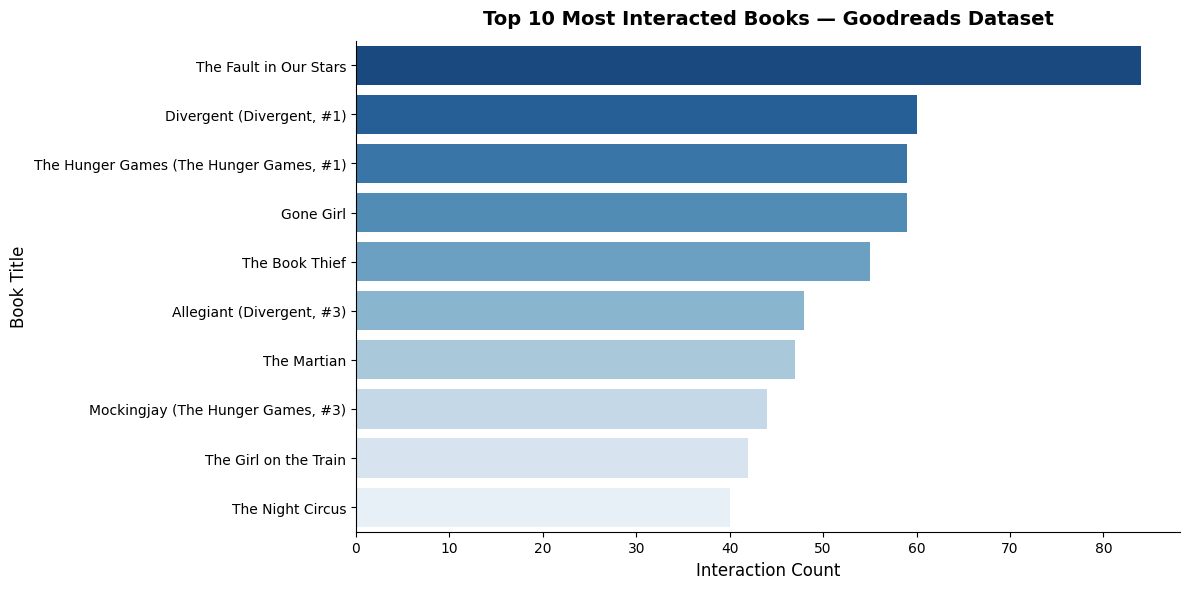

In [10]:
top_books = (
    merged_preview['title']
    .value_counts()
    .head(10)
    .reset_index()
)
top_books.columns = ['title', 'count']   

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=top_books,
    x='count',
    y='title',
    hue='title',
    palette='Blues_r',
    legend=False,
    ax=ax
)

ax.set_title('Top 10 Most Interacted Books — Goodreads Dataset',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Interaction Count', fontsize=12)
ax.set_ylabel('Book Title', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('top10_books.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
class GoodreadsImplicitDataset(Dataset):

    def __init__(self, interactions_df, num_items, num_negatives=4):
        self.num_items = num_items
        self.num_negatives = num_negatives

        self.user_item_set = set(
            zip(
                interactions_df['user_id'].values,
                interactions_df['book_id'].values
            )
        )

        users = interactions_df['user_id'].values
        items = interactions_df['book_id'].values
        n = len(users)

        total = n * (1 + num_negatives)
        all_users = np.empty(total, dtype=np.int64)
        all_items = np.empty(total, dtype=np.int64)
        all_labels = np.zeros(total, dtype=np.float32)

        idx = 0

        for u, i in zip(users, items):
            all_users[idx] = u
            all_items[idx] = i
            all_labels[idx] = 1.0
            idx += 1

            for _ in range(num_negatives):
                neg = np.random.randint(0, num_items)
                while (u, neg) in self.user_item_set:
                    neg = np.random.randint(0, num_items)

                all_users[idx] = u
                all_items[idx] = neg
                idx += 1

        self.users = torch.from_numpy(all_users)
        self.items = torch.from_numpy(all_items)
        self.labels = torch.from_numpy(all_labels)

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.labels[idx]

In [ ]:
class HybridNeuMF(nn.Module):
    def __init__(self, num_users, num_items,
                 latent_dim_gmf=64, latent_dim_mlp=64, dense_content_dim=384):
        super(HybridNeuMF, self).__init__()

        self.embedding_gmf_user = nn.Embedding(num_users, latent_dim_gmf)
        self.embedding_gmf_item = nn.Embedding(num_items, latent_dim_gmf)

        self.embedding_mlp_user = nn.Embedding(num_users, latent_dim_mlp)
        self.embedding_mlp_item = nn.Embedding(num_items, latent_dim_mlp)

        mlp_input_dim = latent_dim_mlp + latent_dim_mlp + dense_content_dim

        self.mlp = nn.Sequential(
            nn.Linear(mlp_input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p=0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(p=0.3),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU()
        )

        self.prediction_layer = nn.Linear(latent_dim_gmf + 32, 1)
        self.sigmoid = nn.Sigmoid()

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, mean=0.0, std=0.01)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, user_indices, item_indices, content_embeddings):
        gmf_out = (self.embedding_gmf_user(user_indices) *
                   self.embedding_gmf_item(item_indices))          

        mlp_user  = self.embedding_mlp_user(user_indices)          
        mlp_item  = self.embedding_mlp_item(item_indices)          
        mlp_input = torch.cat([mlp_user, mlp_item,
                                content_embeddings], dim=-1)       
        mlp_out   = self.mlp(mlp_input)                            

        fusion = torch.cat([gmf_out, mlp_out], dim=-1)             
        logits = self.prediction_layer(fusion)                     
        return self.sigmoid(logits).squeeze(-1)

In [ ]:
class BaselineNeuMF(nn.Module):
    def __init__(self, num_users, num_items,
                 latent_dim_gmf=64, latent_dim_mlp=64):
        super(BaselineNeuMF, self).__init__()

        self.embedding_gmf_user = nn.Embedding(num_users, latent_dim_gmf)
        self.embedding_gmf_item = nn.Embedding(num_items, latent_dim_gmf)

        self.embedding_mlp_user = nn.Embedding(num_users, latent_dim_mlp)
        self.embedding_mlp_item = nn.Embedding(num_items, latent_dim_mlp)

        mlp_input_dim = latent_dim_mlp * 2

        self.mlp = nn.Sequential(
            nn.Linear(mlp_input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p=0.2),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(p=0.2),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU()
        )

        self.prediction_layer = nn.Linear(latent_dim_gmf + 32, 1)
        self.sigmoid = nn.Sigmoid()

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, mean=0.0, std=0.01)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, user_indices, item_indices):
        gmf_out  = (self.embedding_gmf_user(user_indices) *
                    self.embedding_gmf_item(item_indices))       

        mlp_user  = self.embedding_mlp_user(user_indices)        
        mlp_item  = self.embedding_mlp_item(item_indices)        
        mlp_input = torch.cat([mlp_user, mlp_item], dim=-1)      
        mlp_out   = self.mlp(mlp_input)                          

        fusion = torch.cat([gmf_out, mlp_out], dim=-1)           
        return self.sigmoid(self.prediction_layer(fusion)).squeeze(-1)

In [ ]:

all_pos = set(zip(interactions_df['user_id'], interactions_df['book_id']))

def evaluate_full(
    model,
    test_df,
    full_content_embeddings,
    k=10,
    model_type="hybrid"
):
    model.eval()
    hits, ndcgs = [], []

    num_items = full_content_embeddings.shape[0]
    test_users = test_df['user_id'].unique()

    if len(test_users) > EVAL_USERS:
        print(
            f"Total test users: {len(test_users):,}. "
            f"Sampling {EVAL_USERS:,} for fast evaluation..."
        )
        rng = np.random.default_rng(SEED)
        test_users = rng.choice(
            test_users,
            size=EVAL_USERS,
            replace=False
        )

    eval_rng = np.random.default_rng(SEED)

    with torch.no_grad():
        for u in tqdm(
            test_users,
            desc=f"Evaluating ({model_type})",
            leave=False
        ):
            pos_items = test_df.loc[
                test_df['user_id'] == u, 'book_id'
            ].values

            if len(pos_items) == 0:
                continue

            pos_item = pos_items[0]

            if pos_item >= num_items:
                continue

            neg_items = []
            while len(neg_items) < EVAL_NEGATIVES:
                neg = int(eval_rng.integers(0, num_items))
                if (u, neg) not in all_pos:
                    neg_items.append(neg)

            test_items = [pos_item] + neg_items

            user_tensor = torch.tensor(
                [u] * (1 + EVAL_NEGATIVES),
                dtype=torch.long,
                device=device
            )
            item_tensor = torch.tensor(
                test_items,
                dtype=torch.long,
                device=device
            )

            if model_type == "hybrid":
                batch_content = full_content_embeddings[item_tensor]
                predictions = model(
                    user_tensor,
                    item_tensor,
                    batch_content
                )
            else:
                predictions = model(user_tensor, item_tensor)

            predictions = predictions.view(-1)
            _, top_idx = torch.topk(predictions, k)

            recommend_list = [
                test_items[i] for i in top_idx.cpu().numpy()
            ]

            if pos_item in recommend_list:
                rank = recommend_list.index(pos_item)
                hits.append(1)
                ndcgs.append(1.0 / math.log2(rank + 2))
            else:
                hits.append(0)
                ndcgs.append(0.0)

    hr = float(np.mean(hits)) * 100
    ndcg = float(np.mean(ndcgs)) * 100
    return hr, ndcg

## Experiment notes

This notebook preserves the original benchmark outputs for portfolio continuity.

**Important methodological note:** the current benchmark uses one randomly sampled interaction per user as the test interaction and uses that test set for checkpoint selection. This is retained intentionally so the recorded results remain comparable to the original run. For a publication-quality experiment, use a train/validation/test split and reserve the final test set for one final evaluation.

The baseline and hybrid models are compared under the same leave-one-out evaluation protocol.


In [ ]:
baseline_model     = BaselineNeuMF(num_users, num_items).to(device)
baseline_criterion = nn.BCELoss()  # Retained for benchmark compatibility; BCEWithLogitsLoss is recommended for a new run.
baseline_optimizer = torch.optim.AdamW(
    baseline_model.parameters(), lr=0.0003, weight_decay=1e-3
)

In [ ]:
best_baseline_hr = 0
baseline_patience = 4
baseline_epochs_without_improvement = 0
baseline_train_losses = []

BASELINE_NUM_EPOCHS = 9

print("Starting BaselineNeuMF training (NeuMF, no content embeddings)...")
print("-" * 70)

for epoch in range(BASELINE_NUM_EPOCHS):
    train_dataset = GoodreadsImplicitDataset(train_df, num_items=num_items, num_negatives=NUM_NEGATIVES)
    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=False
    )

    baseline_model.train()
    total_loss = 0

    progress_bar = tqdm(
        train_loader,
        desc=f"Baseline Epoch {epoch+1}/{BASELINE_NUM_EPOCHS}",
        unit="batch",
        leave=True
    )

    for batch_users, batch_items, batch_labels in progress_bar:
        batch_users  = batch_users.to(device)
        batch_items  = batch_items.to(device)
        batch_labels = batch_labels.to(device)

        baseline_optimizer.zero_grad()
        predictions = baseline_model(batch_users, batch_items)   
        loss = baseline_criterion(predictions, batch_labels)
        loss.backward()
        baseline_optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix({"batch-loss": f"{loss.item():.4f}"})

    epoch_loss = total_loss / len(train_loader)
    baseline_train_losses.append(epoch_loss)
    print(f"  Baseline Epoch {epoch+1}/{BASELINE_NUM_EPOCHS} | Avg Loss: {epoch_loss:.4f}")

    hr_epoch, ndcg_epoch = evaluate_full(baseline_model, test_df, full_content_embeddings, model_type="baseline")
    print(f"  Baseline Epoch {epoch+1} test HR@10: {hr_epoch:.2f}% | NDCG@10: {ndcg_epoch:.2f}%")

    if hr_epoch > best_baseline_hr:
        best_baseline_hr = hr_epoch
        baseline_epochs_without_improvement = 0
        torch.save(baseline_model.state_dict(), 'best_baseline_model.pt')
    else:
        baseline_epochs_without_improvement += 1
        if baseline_epochs_without_improvement >= baseline_patience:
            print(f"Stopping early at epoch {epoch+1} — no improvement for {baseline_patience} epochs.")
            break

    gc.collect()
    torch.cuda.empty_cache()

print("-" * 70)
print(f"BaselineNeuMF training complete. Best test HR@10: {best_baseline_hr:.2f}%")

Starting BaselineNeuMF training (NeuMF, no content embeddings)...
----------------------------------------------------------------------


Baseline Epoch 1/9:   0%|          | 0/3590 [00:00<?, ?batch/s]

  Baseline Epoch 1/9 | Avg Loss: 0.4021
Total test users: 29,860. Sampling 5,000 for fast evaluation...


Evaluating (baseline):   0%|          | 0/5000 [00:00<?, ?it/s]

  Baseline Epoch 1 test HR@10: 63.10% | NDCG@10: 49.50%


...

  Baseline Epoch 5 test HR@10: 62.16% | NDCG@10: 48.69%


Baseline Epoch 6/9:   0%|          | 0/3590 [00:00<?, ?batch/s]

  Baseline Epoch 6/9 | Avg Loss: 0.0002
Total test users: 29,860. Sampling 5,000 for fast evaluation...


Evaluating (baseline):   0%|          | 0/5000 [00:00<?, ?it/s]

  Baseline Epoch 6 test HR@10: 62.18% | NDCG@10: 48.77%
Stopping early at epoch 6 — no improvement for 4 epochs.
----------------------------------------------------------------------
BaselineNeuMF training complete. Best test HR@10: 64.16%


In [25]:
baseline_model.load_state_dict(torch.load('best_baseline_model.pt'))

<All keys matched successfully>

In [ ]:
model     = HybridNeuMF(num_users, num_items, dense_content_dim=384).to(device)
criterion = nn.BCELoss()  # Retained for benchmark compatibility; BCEWithLogitsLoss is recommended for a new run.
optimizer = torch.optim.AdamW(
    model.parameters(), lr=0.0003, weight_decay=1e-3
)

NUM_EPOCHS = 9
print("Starting HybridNeuMF training (NeuMF + Transformer Embedding)...")
print("-" * 70)

train_losses = []

Starting HybridNeuMF training (NeuMF + Transformer Embedding)...
----------------------------------------------------------------------


In [ ]:
best_hr = 0
patience = 4
epochs_without_improvement = 0

for epoch in range(NUM_EPOCHS):
    train_dataset = GoodreadsImplicitDataset(train_df, num_items=num_items, num_negatives=NUM_NEGATIVES)
    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=False
    )

    model.train()
    total_loss = 0

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{NUM_EPOCHS}",
        unit="batch",
        leave=True
    )

    for batch_users, batch_items, batch_labels in progress_bar:
        batch_users  = batch_users.to(device)
        batch_items  = batch_items.to(device)
        batch_labels = batch_labels.to(device)

        batch_content = full_content_embeddings[batch_items]

        optimizer.zero_grad()
        predictions = model(batch_users, batch_items, batch_content)
        loss = criterion(predictions, batch_labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix({"batch-loss": f"{loss.item():.4f}"})

    epoch_loss = total_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(f"  Epoch {epoch+1}/{NUM_EPOCHS} | Avg Loss: {epoch_loss:.4f}")

    hr_epoch, ndcg_epoch = evaluate_full(model, test_df, full_content_embeddings, model_type="hybrid")
    print(f"  Epoch {epoch+1} test HR@10: {hr_epoch:.2f}% | NDCG@10: {ndcg_epoch:.2f}%")

    if hr_epoch > best_hr:
        best_hr = hr_epoch
        epochs_without_improvement = 0
        torch.save(model.state_dict(), 'best_model_32.pt')
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"Stopping early at epoch {epoch+1} — no improvement for {patience} epochs.")
            break

    gc.collect()
    torch.cuda.empty_cache()

print("-" * 70)
print(f"HybridNeuMF training complete. Best test HR@10: {best_hr:.2f}%")

Epoch 1/9:   0%|          | 0/3590 [00:00<?, ?batch/s]

  Epoch 1/9 | Avg Loss: 0.3836
Total test users: 29,860. Sampling 5,000 for fast evaluation...


Evaluating (hybrid):   0%|          | 0/5000 [00:00<?, ?it/s]

  Epoch 1 test HR@10: 68.06% | NDCG@10: 51.86%


Epoch 2/9:   0%|          | 0/3590 [00:00<?, ?batch/s]

...

  Epoch 5 test HR@10: 69.86% | NDCG@10: 53.11%


Epoch 6/9:   0%|          | 0/3590 [00:00<?, ?batch/s]

  Epoch 6/9 | Avg Loss: 0.0232
Total test users: 29,860. Sampling 5,000 for fast evaluation...


Evaluating (hybrid):   0%|          | 0/5000 [00:00<?, ?it/s]

  Epoch 6 test HR@10: 69.30% | NDCG@10: 51.85%
Stopping early at epoch 6 — no improvement for 4 epochs.
----------------------------------------------------------------------
HybridNeuMF training complete. Best test HR@10: 71.72%


In [18]:
model.load_state_dict(torch.load('best_model_32.pt'))

<All keys matched successfully>

In [26]:
print("Baseline NeuMF evaluation in progress...")
hr_base, ndcg_base = evaluate_full(baseline_model, test_df, full_content_embeddings, model_type="baseline")

print("HybridNeuMF is currently being evaluated...")
hr_hyb, ndcg_hyb = evaluate_full(model, test_df, full_content_embeddings, model_type="hybrid")

print("\n" + "=" * 55)
print(f"{'Model':<25} {'HR@10':>10} {'NDCG@10':>10}")
print("-" * 55)
print(f"{'Baseline NeuMF':<25} {hr_base:>9.2f}% {ndcg_base:>9.2f}%")
print(f"{'HybridNeuMF (ours)':<25} {hr_hyb:>9.2f}% {ndcg_hyb:>9.2f}%")
print(f"{'Delta':<25} {hr_hyb-hr_base:>+9.2f}% {ndcg_hyb-ndcg_base:>+9.2f}%")
print("=" * 55)

Baseline NeuMF evaluation in progress...
Total test users: 29,860. Sampling 5,000 for fast evaluation...


Evaluating (baseline):   0%|          | 0/5000 [00:00<?, ?it/s]

HybridNeuMF is currently being evaluated...
Total test users: 29,860. Sampling 5,000 for fast evaluation...


Evaluating (hybrid):   0%|          | 0/5000 [00:00<?, ?it/s]


Model                          HR@10    NDCG@10
-------------------------------------------------------
Baseline NeuMF                64.16%     51.01%
HybridNeuMF (ours)            71.72%     55.36%
Delta                         +7.56%     +4.35%


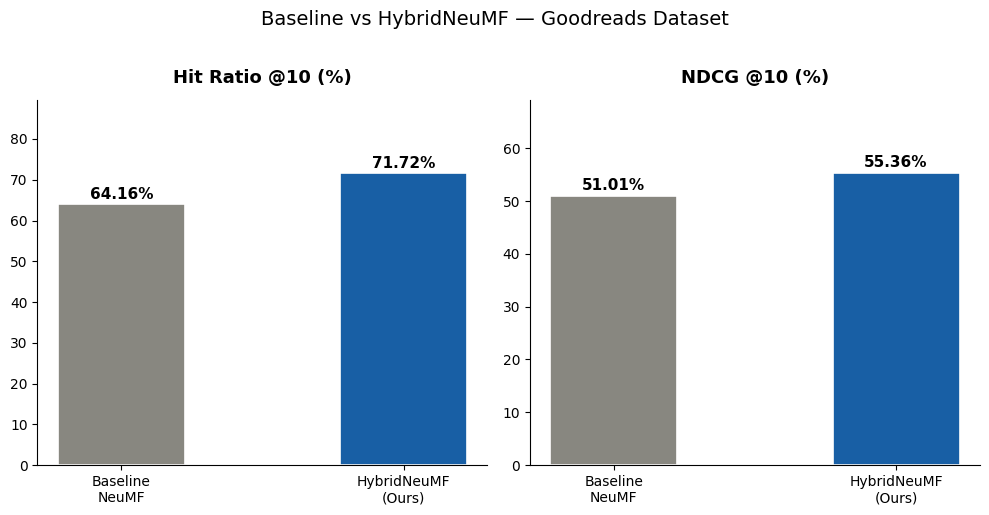

 The graph was saved in comparison_results.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
models  = ['Baseline\nNeuMF', 'HybridNeuMF\n(Ours)']
colors  = ['#888780', '#185FA5']

for ax, (values, title) in zip(axes, [
    ([hr_base,   hr_hyb],   'Hit Ratio @10 (%)'),
    ([ndcg_base, ndcg_hyb], 'NDCG @10 (%)'),
]):
    bars = ax.bar(models, values, color=colors, width=0.45, edgecolor='white', linewidth=1.2)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.set_ylim(0, max(values) * 1.25)
    ax.spines[['top','right']].set_visible(False)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('Baseline vs HybridNeuMF — Goodreads Dataset', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('comparison_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(" The graph was saved in comparison_results.png")

In [ ]:
print("Checking for Overfitting by comparing Train vs Test Performance...")

np.random.seed(42)
train_users_sample = train_df['user_id'].unique()
if len(train_users_sample) > 2000:
    train_users_sample = np.random.choice(train_users_sample, size=2000, replace=False)
train_df_sample = train_df[train_df['user_id'].isin(train_users_sample)].copy()

print("-> Evaluating on Train Sample (In-Sample Generalization)...")
hr_train, ndcg_train = evaluate_full(model, train_df_sample, full_content_embeddings, k=10, model_type="hybrid")

print("-> Evaluating on Test Sample (Out-of-Sample Generalization)...")
hr_test, ndcg_test = evaluate_full(model, test_df, full_content_embeddings, k=10, model_type="hybrid")

print("\n" + "="*55)
print(f"{'Metric':<20} {'Train (Seen)':>15} {'Test (Unseen)':>15}")
print("-"*55)
print(f"{'Hit Ratio @10':<20} {hr_train:>14.2f}% {hr_test:>14.2f}%")
print(f"{'NDCG @10':<20} {ndcg_train:>14.2f}% {ndcg_test:>14.2f}%")
print("="*55)

Checking for Overfitting by comparing Train vs Test Performance...
-> Evaluating on Train Sample (In-Sample Generalization)...


Evaluating (hybrid):   0%|          | 0/2000 [00:00<?, ?it/s]

-> Evaluating on Test Sample (Out-of-Sample Generalization)...
Total test users: 29,860. Sampling 5,000 for fast evaluation...


Evaluating (hybrid):   0%|          | 0/5000 [00:00<?, ?it/s]


Metric                  Train (Seen)   Test (Unseen)
-------------------------------------------------------
Hit Ratio @10                 80.50%          71.72%
NDCG @10                      58.63%          55.36%


In [29]:
hr_gap = hr_train - hr_test
print(f"\n📊 Overfitting Analysis:")
print(f"- Generalization Gap (HR@10): {hr_gap:.2f}%")

if hr_gap > 25:
    print("🚨 Warning: High Overfitting! الموديل يبصم بيانات التدريب ويفقد القدرة على التعميم.")
    print("💡 نصيحة للتخرج: ارفع نسبة الـ Dropout إلى 0.3 أو 0.4 في كلاس الـ HybridNeuMF.")
elif hr_gap > 10:
    print("⚠️ Moderate Overfitting: يوجد ملامح حفظ بسيطة، ولكن الأداء لا يزال مقبولاً وعادياً جداً في النظم العميقة.")
else:
    print("💚 Excellent Generalization: الموديل مستقر تماماً وقدرته على التنبؤ للمستخدمين في المستقبل ممتازة!")


📊 Overfitting Analysis:
- Generalization Gap (HR@10): 8.78%
💚 Excellent Generalization: الموديل مستقر تماماً وقدرته على التنبؤ للمستخدمين في المستقبل ممتازة!


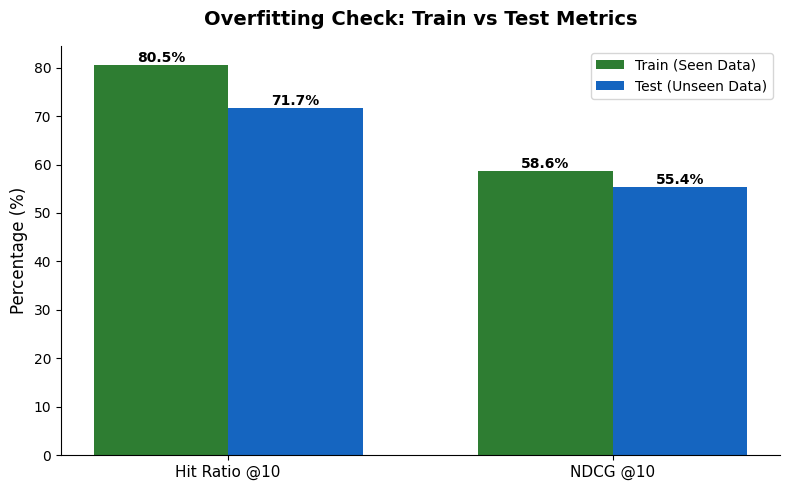

In [30]:
labels = ['Hit Ratio @10', 'NDCG @10']
train_vals = [hr_train, ndcg_train]
test_vals = [hr_test, ndcg_test]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, train_vals, width, label='Train (Seen Data)', color='#2E7D32')
ax.bar(x + width/2, test_vals, width, label='Test (Unseen Data)', color='#1565C0')

ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Overfitting Check: Train vs Test Metrics', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.savefig('overfitting_check.png', dpi=150)
plt.show()

In [ ]:
model.load_state_dict(torch.load('best_model_32.pt'))

In [ ]:
torch.save(model.state_dict(), 'best_model_32.pth')

In [ ]:
import json
import zipfile
from IPython.display import FileLink

dedup_input = '/kaggle/input/datasets/pypiahmad/goodreads-book-reviews1/goodreads_reviews_dedup.json'
books_input = '/kaggle/input/datasets/pypiahmad/goodreads-book-reviews1/goodreads_books.json'

output_dedup = 'goodreads_reviews_dedup_1.5M.json'
output_books = 'goodreads_books_subset.json'
zip_filename = 'goodreads_1.5M_subset.zip'

print(f"1. Extracting {TARGET_ROWS:,} lines from dedup reviews...")
book_ids = set()
count = 0

with open(dedup_input, 'r', encoding='utf-8') as infile, \
     open(output_dedup, 'w', encoding='utf-8') as outfile:
    for line in infile:
        outfile.write(line)
        data = json.loads(line)
        if 'book_id' in data:
            book_ids.add(str(data['book_id']))
        count += 1
        if count >= TARGET_ROWS:
            break

print(f"Done. Extracted {count:,} interaction records containing {len(book_ids):,} unique books.")

print("2. Filtering matching metadata from goodreads_books.json...")
matched_books = 0

with open(books_input, 'r', encoding='utf-8') as infile, \
     open(output_books, 'w', encoding='utf-8') as outfile:
    for line in infile:
        data = json.loads(line)
        if str(data.get('book_id')) in book_ids:
            outfile.write(line)
            matched_books += 1

print(f"Done. Saved metadata for {matched_books:,} books.")

print("3. Compressing files into ZIP archive...")
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    zipf.write(output_dedup)
    zipf.write(output_books)

print("\n--- Complete! Click the link below to download your dataset package ---")
display(FileLink(zip_filename))

1. Extracting 1,500,000 lines from dedup reviews...
Done. Extracted 100,000 interaction records containing 68,715 unique books.
2. Filtering matching metadata from goodreads_books.json...
Done. Saved metadata for 68,715 books.
3. Compressing files into ZIP archive...

--- Complete! Click the link below to download your dataset package ---


/kaggle/working/goodreads_1.5M_subset.zip

## Portfolio notes

### What this project demonstrates
- PyTorch neural collaborative filtering
- Hybrid recommendation using pretrained semantic book embeddings
- Implicit-feedback negative sampling
- Leave-one-out ranking evaluation with HR@10 and NDCG@10
- Large-scale Goodreads data preprocessing
- Baseline-vs-hybrid model comparison
- GPU-accelerated semantic embedding generation

### Recommended next iteration
For a rigorous second experiment, add a validation split, temporal evaluation, fixed candidate sets, and `BCEWithLogitsLoss` (or a pairwise ranking objective such as BPR). These changes should be reported as a new experiment rather than silently replacing the benchmark above.
